In [2]:
from importlib.metadata import version

print("torch version:", version("torch"))

torch version: 2.5.1


# 为什么需要位置编码

In [3]:
import torch.nn as nn
import torch.nn.functional as F
import torch
import math
from dataclasses import dataclass

@dataclass
class ModelArgs:
    n_heads: int
    dim: int
    dropout: float
    max_seq_len: int

'''多头自注意力核心代码'''
class MultiHeadAttention(nn.Module):

    def __init__(self, args: ModelArgs, is_causal=False):
        
        # 初始化父类
        super().__init__()
        
        # 隐藏维度必须被头整除
        assert args.dim % args.n_heads == 0
        
        # 每个头的维度，等于模型维度除以头的总数。
        self.head_dim = args.dim // args.n_heads
        
        # 成员变量赋值
        self.n_heads = args.n_heads
        self.is_causal = is_causal

        # Wq, Wk, Wv变换矩阵，shape=[dim, dim], 注意：self.n_heads * self.head_dim=args.dim
        self.wq = nn.Linear(args.dim, self.n_heads * self.head_dim, bias=False)
        self.wk = nn.Linear(args.dim, self.n_heads * self.head_dim, bias=False)
        self.wv = nn.Linear(args.dim, self.n_heads * self.head_dim, bias=False)
        
        # 输出变换矩阵，shape=[dim, dim]
        self.wo = nn.Linear(self.n_heads * self.head_dim, args.dim, bias=False)
         
        # 掩码上三角矩阵，屏蔽未来的token
        if is_causal:
           mask = torch.full((1, 1, args.max_seq_len, args.max_seq_len), float("-inf"))
           mask = torch.triu(mask, diagonal=1)
            
           # 注册缓冲区
           self.register_buffer("mask", mask)

    
    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor):

        # [batch_size, seq_len, dim]
        batch_size, seq_len, dim = q.shape

        # 计算Q,K,V，维度为 (batch_size, seq_len, dim) x (dim, dim) -> (batch_size, seq_len, dim)
        Q, K, V = self.wq(q), self.wk(k), self.wv(v)

        # 将 Q、K、V 拆分成多头，shape=(batch_size, seq_len, n_heads, head_dim)
        Q = Q.view(batch_size, seq_len, self.n_heads, self.head_dim)
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim)
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim)

        # 交换位置1和位置2，shape=(batch_size, n_heads, seq_len, head_dim)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)


        # 注意力计算
        # QK^T / sqrt(d_k)，(batch_size, n_heads, seq_len, head_dim) x (batch_size, n_heads, head_dim, seq_len) -> (batch_size, n_heads, seq_len, seq_len)
        scores = torch.matmul(Q, K.transpose(2, 3)) / math.sqrt(self.head_dim)
        
        # 计算掩码
        if self.is_causal:
            # 直接相加，-inf叠加的位置就等于mask掉了, max_seq_len可能大于seq_len
            scores = scores + self.mask[:, :, :seq_len, :seq_len]
            
        # 计算 softmax，shape=(batch_size, n_heads, seq_len, seq_len)
        scores = F.softmax(scores.float(), dim=-1).type_as(Q)
        
        
        # 计算注意力加权输出，V * Score，维度为(batch_size, n_heads, seq_len, seq_len) x (batch_size, n_heads, seq_len, head_dim) -> (batch_size, n_heads, seq_len, head_dim)
        output = torch.matmul(scores, V)

        # 拼接多头注意力结果，(batch_size, n_heads, seq_len, head_dim) => (batch_size, seq_dim, dim)
        output = output.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)

        # 输出层+残差
        output = self.wo(output)
        
        return output, scores

In [4]:
# 固定随机种子
torch.manual_seed(42)
torch.cuda.manual_seed_all(42) 

embs = {
    "金毛": [0.2, 0.4, 0.8, -0.1],
    "西瓜": [-3.7, -4.2, 1.1, 2.1],
    "丁师兄": [-2.4, 0.1, -0.3, 4.5]
}

x1 = torch.FloatTensor([[embs["金毛"], embs["西瓜"], embs["丁师兄"]]])
x2 = torch.FloatTensor([[embs["西瓜"], embs["金毛"], embs["丁师兄"]]])

args = ModelArgs(n_heads=2, dim=4, dropout=0.1, max_seq_len=10)

# MHA
mha = MultiHeadAttention(args, is_causal=False)

output1, _  = mha(x1, x1, x1)
output2, _  = mha(x2, x2, x2)
print("x1 output: ", output1)
print("x2 output: ", output2)

x1 output:  tensor([[[-0.3349, -0.0581,  0.2855,  0.3849],
         [-0.3327, -0.2689,  0.5470,  0.9469],
         [-0.2949, -0.3604,  0.7417,  0.6260]]], grad_fn=<UnsafeViewBackward0>)
x2 output:  tensor([[[-0.3327, -0.2689,  0.5470,  0.9469],
         [-0.3349, -0.0581,  0.2855,  0.3849],
         [-0.2949, -0.3604,  0.7417,  0.6260]]], grad_fn=<UnsafeViewBackward0>)


# Mask注意力

In [5]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42) 

mha = MultiHeadAttention(args, is_causal=True)

output1, _  = mha(x1, x1, x1)
output2, _  = mha(x2, x2, x2)
print("x1 output: ", output1)
print("x2 output: ", output2)

x1 output:  tensor([[[-0.1697,  0.1701, -0.0406, -0.1006],
         [ 0.0420, -0.2777, -0.0731,  0.7281],
         [-0.2949, -0.3604,  0.7417,  0.6260]]], grad_fn=<UnsafeViewBackward0>)
x2 output:  tensor([[[-0.3272, -0.1721,  0.1728,  0.8592],
         [-0.3842,  0.0816,  0.1442,  0.3253],
         [-0.2949, -0.3604,  0.7417,  0.6260]]], grad_fn=<UnsafeViewBackward0>)


# 三角位置编码

In [6]:
@dataclass
class Args:
    max_seq_len: int
    dim: int
class PositionEncoding(nn.Module):
    def __init__(self, args: Args):
        super().__init__()
        self.pe = torch.zeros(args.max_seq_len, args.dim)
        self.position = torch.arange(0,args.max_seq_len).unsqueeze(1)
        '''
        PE(pos, 2i)   = sin( pos / 10000^(2i/d) )
        PE(pos, 2i+1) = cos( pos / 10000^(2i/d) )
        1 / 10000^(2i/d)
        = 10000^(-2i/d)
        = exp( ln(10000^(-2i/d)) )         ← 任何 a = exp(ln(a))
        = exp( (-2i/d) · ln(10000) )       ← log 性质:ln(a^b) = b·ln(a)
        = exp( 2i · (-ln(10000) / d) )     ← 把负号和除法挪进去
            ↑              ↑
        arange(0,d,2)   -math.log(10000.0)/d
        '''
        factor = torch.exp(torch.arange(0, args.dim, 2) * (-math.log(10000.0) / args.dim))

        # 计算 PE(pos, 2i)
        # 偶数部分
        self.pe[:, 0::2] = torch.sin(self.position * factor)
        # 奇数部分
        self.pe[:, 1::2] = torch.cos(self.position * factor)

        # 插入 batch 维度 [1, max_seq_len, dim]
        self.pe = self.pe.unsqueeze(0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.pe
        return x


In [7]:
args = Args(max_seq_len=512, dim=1024)
print(args)

position_encoder = PositionEncoding(args)
print(position_encoder.pe.shape)

Args(max_seq_len=512, dim=1024)
torch.Size([1, 512, 1024])


In [8]:
print(position_encoder.pe[0, 0])
print(position_encoder.pe[0, 1])
print(position_encoder.pe[0, 511])

tensor([0., 1., 0.,  ..., 1., 0., 1.])
tensor([8.4147e-01, 5.4030e-01, 8.3171e-01,  ..., 1.0000e+00, 1.0182e-04,
        1.0000e+00])
tensor([ 0.8818, -0.4717, -0.6925,  ...,  0.9986,  0.0520,  0.9986])


(512, 1024)


<Axes: >

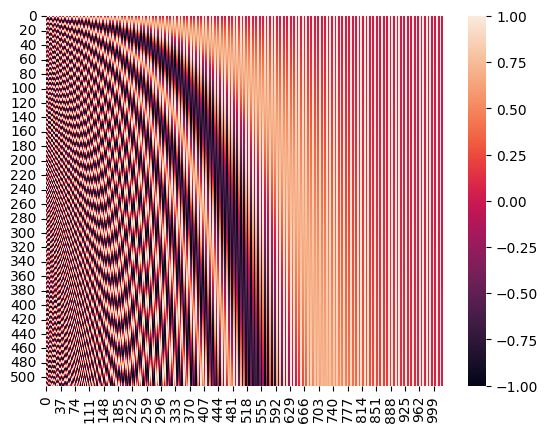

In [9]:
import seaborn as sns

# 热力图

print(position_encoder.pe[0].detach().numpy().shape)

sns.heatmap(position_encoder.pe[0].detach().numpy())